In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import torch
import tqdm
import xarray as xr

# Local imports
import include as base
%matplotlib inline

---
# Load data
---

In [2]:
# Country coordinates
country_coords = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Coordinates.csv", index_col=2)
country_coords = country_coords[~country_coords.index.duplicated()]

# Conversion table for ISO3 codes
iso3_to_name = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Iso_code_lookup.csv").set_index('Alpha-3 code')['Country'].to_dict()

In [3]:
# Define the time period
start, end = 1990, 2021

In [319]:
# Load the UN net migration data, total population, stock data
UN_data = xr.load_dataset("../../../data/Migration/UN_data.nc")
net_migration = UN_data['Net Number of Migrants (thousands)'].transpose('Year', ...).sel({'Year': range(start, end + 1)})
total_population = UN_data['Total Population, as of 1 January (thousands)'].transpose('Year', ...).sel({'Year': range(start, end + 1)})
stock_data = xr.load_dataarray("../../../data/Migration/UN_stock_data_ext.nc").transpose("Year", ...).sel({"Year": np.arange(start, end + 1, 5)}) / 1000
stock_diff = stock_data.diff("Year")
Y = net_migration.shape[0]
N = net_migration.shape[1]
print(Y, N)

32 236


---
# Rescale data
---

In [320]:
# Get the scaling parameters for the data
# Net migration
alpha = np.nanstd(net_migration.data, axis=-1)
alpha = np.where(alpha > 0, alpha, 1)

# Stock difference
beta = np.nanstd(stock_diff.data, axis=-1)
beta = np.where(beta > 0, beta, 1)
beta_extend = np.concatenate(
    [np.concatenate([np.repeat([beta[i]], 5, axis=0) for i in range(len(beta))]), (Y % 5) * [beta[-1]]]
)

# Total population
gamma = np.nanstd(total_population, axis=-1)

print(f"Shapes: alpha: {alpha.shape}, beta: {beta.shape}, beta (extended): {beta_extend.shape}, gamma: {gamma.shape}")

Shapes: alpha: (32,), beta: (6, 236), beta (extended): (32, 236), gamma: (32,)


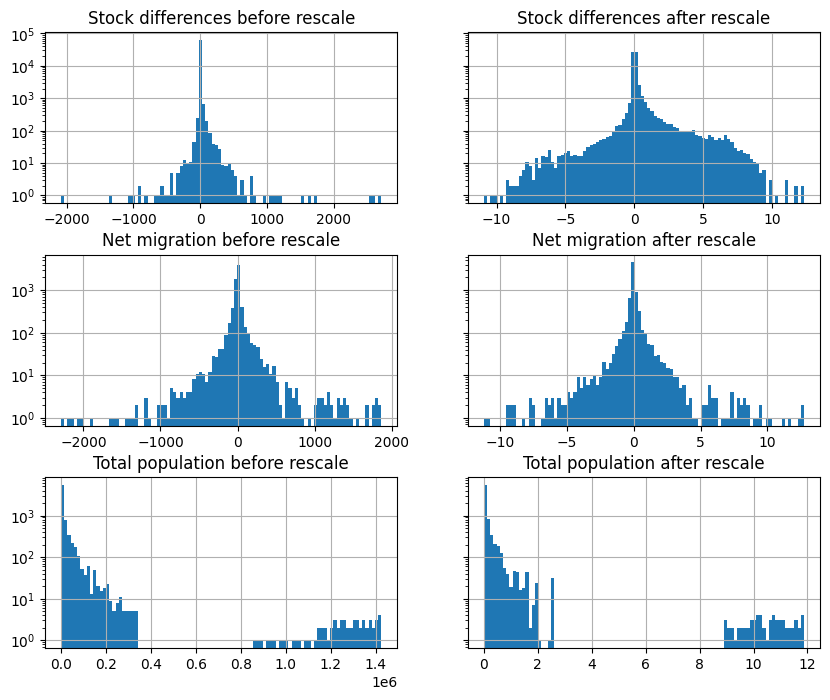

In [322]:
# Plot the rescaled data
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharey='row')

# Rescaled stock data
axs[0, 0].set_title("Stock differences before rescale")
axs[0, 1].set_title("Stock differences after rescale")
axs[0, 0].hist(stock_diff.data.flatten(), bins=100)
axs[0, 1].hist((stock_diff.data / beta.reshape(-1, N, 1)).flatten(), bins=100)

# Rescaled net migration
axs[1, 0].set_title("Net migration before rescale")
axs[1, 1].set_title("Net migration after rescale")
axs[1, 0].hist(net_migration.data.flatten(), bins=100)
axs[1, 1].hist((net_migration.data / alpha.reshape(Y, 1)).flatten(), bins=100)

# Rescaled total population
axs[2, 0].set_title("Total population before rescale")
axs[2, 1].set_title("Total population after rescale")
axs[2, 0].hist(total_population.data.flatten(), bins=100)
axs[2, 1].hist((total_population.data / gamma.reshape(Y, 1)).flatten(), bins=100)

for ax in axs.flatten():
    ax.set_yscale('log')
    ax.grid()

fig.subplots_adjust(wspace=0.2, hspace=0.3)

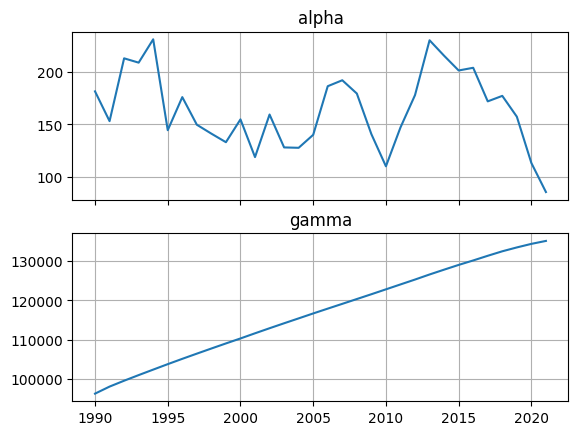

In [323]:
# Plot the alpha and gamma scaling over time
fig, axs = plt.subplots(nrows=2, sharex=True)
axs[0].plot(net_migration.coords["Year"].data, alpha)
axs[1].plot(net_migration.coords["Year"].data, gamma)
axs[0].set_title("alpha")
axs[1].set_title("gamma")
for ax in axs:
    ax.grid()

---
# Convert to torch.Tensor
---

In [324]:
# Net migration training data (rescaled)
mu_rescaled = torch.from_numpy(net_migration.data / alpha.reshape(Y, 1)).float()

# Stock training data (rescaled). NaN values are masked
N_rescaled = torch.from_numpy(stock_data.data[:-1] / beta.reshape(-1, N, 1)).float()
dN_rescaled = torch.from_numpy(stock_diff.data / beta.reshape(-1, N, 1)).float()
dN_mask = ~torch.isnan(dN_rescaled)

# Population data (rescaled)
p_rescaled = torch.from_numpy(total_population.data / gamma.reshape(Y, 1)).float()

---
# Setup and train the neural network
---

In [590]:
NN = base.NeuralNet(
    input_size=N,
    output_size=2*N**2,
    num_layers=3,
    nodes_per_layer=dict(default=20),
    activation_funcs=dict(default='sigmoid', layer_specific={1: 'sigmoid', -1: 'abs'}),
    biases=dict(default=None), 
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.002)
)

# Store training loss by components
loss_dict = {
    'stock': [], 'neg_stock': [], 'net_migration': [], 'trace': [], 'upper_bound': [], 'sum': []
}

In [591]:
# Define some transformation matrices
# Transform from beta to mu-scaling
BM = torch.from_numpy(beta_extend.reshape(Y, N, 1) / alpha.reshape(-1, 1, 1)).reshape(-1, 1, N, 1).float()

# Transform from beta to p-scaling
BP = torch.from_numpy(beta_extend.reshape(Y, N, 1) / gamma.reshape(-1, 1, 1)).reshape(-1, 1, N, 1).float()

# Transform from mu-scaling to p-scaling
MP = torch.from_numpy(gamma / alpha).reshape(Y, 1, 1, 1).float()

# Transform from p-scaling to mu-scaling
PM = torch.from_numpy(alpha / gamma).reshape(Y, 1, 1, 1).float()

In [668]:
perturbation = 0e-2
_lambda = 1e-4

In [669]:
# Define a single training step
def _step(*, Y_range: tuple, stock_loss: bool = True) -> dict:
    
    """
    :param Y_range: the range of years to consider
    :return: dictionary of losses for each component in `which`
    """
    
    _l_dict = {}
    
    # Total loss
    loss = torch.tensor(0.0)
    
    # Make a (transformed) prediction, of shape L, 2, N, N
    prediction_b = NN(mu_rescaled[slice(*Y_range)]).reshape(-1, 2, N, N)

    # Perturb the prediction
    prediction_b = prediction_b * torch.normal(1.0, perturbation, prediction_b.shape)
    
    # Calculate the stock difference on the transformed data, if given
    if stock_loss:
        N_idx = int(np.floor(Y_range[0]/5))
        predicted_stock_diff = (prediction_b[:, 0, :] - prediction_b[:, 1, :]).sum(dim=0) #.reshape(N**2)
        stock_err = torch.pow(predicted_stock_diff[dN_mask[N_idx]] - dN_rescaled[N_idx][dN_mask[N_idx]], 2).sum()
        loss = loss + stock_err
        _l_dict['stock'] = stock_err.clone().detach()
        
        # Penalise negative stock
        neg_stock_err = torch.relu(-predicted_stock_diff[dN_mask[N_idx]] - N_rescaled[N_idx][dN_mask[N_idx]]).sum()
        _l_dict['neg_stock'] = neg_stock_err.clone().detach()
        loss = loss + neg_stock_err

    # Transform the prediction to mu-scaling
    prediction_m = prediction_b * BM[slice(*Y_range)]

    # Calculate the total inflow and outflow
    predicted_outflow = (prediction_m[:, 0, :] + prediction_m.transpose(-2, -1)[:, 1, :]).sum(dim=-1)
    predicted_inflow = (prediction_m.transpose(-2, -1)[:, 0, :] + prediction_m[:, 1, :]).sum(dim=-1)

    # Calculate the predicted net migration
    predicted_net_migration = predicted_inflow - predicted_outflow
    net_migr_err = torch.pow(predicted_net_migration - mu_rescaled[slice(*Y_range)], 2).sum()
    loss = loss + net_migr_err
    _l_dict['net_migration'] = net_migr_err.clone().detach()
    
    # Penalise the trace
    trace_err = torch.diagonal(prediction_m.sum(dim=1), dim1=-2, dim2=-1).sum()
    loss = loss + trace_err
    _l_dict['trace'] = trace_err.clone().detach()
    
    # # Penalise outflow exceeding total population
    # prediction_p = prediction_b * BP[slice(*Y_range)]
    # predicted_outflow = (prediction_p[:, 0, :] + prediction_p.transpose(-2, -1)[:, 1, :]).sum(dim=-1)
    # predicted_inflow = (prediction_p.transpose(-2, -1)[:, 0, :] + prediction_p[:, 1, :]).sum(dim=-1)
    # inflow_err = torch.relu(predicted_inflow - p_rescaled[slice(*Y_range), :]).sum()
    # outflow_err = torch.relu(predicted_outflow - p_rescaled[slice(*Y_range), :]).sum()
    # loss = loss + inflow_err
    # loss = loss  + outflow_err
    # _l_dict['upper_bound'] = inflow_err.clone().detach() + outflow_err.clone().detach()
    # 
    # # Regularise
    # sum_err = prediction_b.sum()
    # # loss = loss + _lambda * sum_err
    # _l_dict['sum'] = _lambda * sum_err.clone().detach()
    # 
    # Perform gradient descent step
    loss.backward()
    NN.optimizer.step()
    NN.optimizer.zero_grad()
    
    return _l_dict

In [678]:
for _ in (pbar:=tqdm.tqdm(range(4000))):
    
    epoch_loss = dict((k, []) for k in loss_dict.keys())
    
    for b in range(len(dN_rescaled)):
        
        _l = _step(Y_range=(5*b, (b+1)*5))
        for key in _l.keys():
            epoch_loss[key].append(_l[key])
    
    # Years 2020 and 2021 must be treated separately, because no stock
    _l = _step(Y_range=(-2, None), stock_loss=False)
    for key in _l.keys():
        epoch_loss[key].append(_l[key])
    
    # Epoch loss
    for key in epoch_loss.keys():
        if epoch_loss[key]:
            loss_dict[key].append(np.mean(epoch_loss[key]))
    # pbar.set_description(f"Stock: {loss_dict['stock'][-1]} | Net migr: {loss_dict['net_migration'][-1]}")

 55%|█████▍    | 2199/4000 [04:02<03:18,  9.07it/s]


KeyboardInterrupt: 

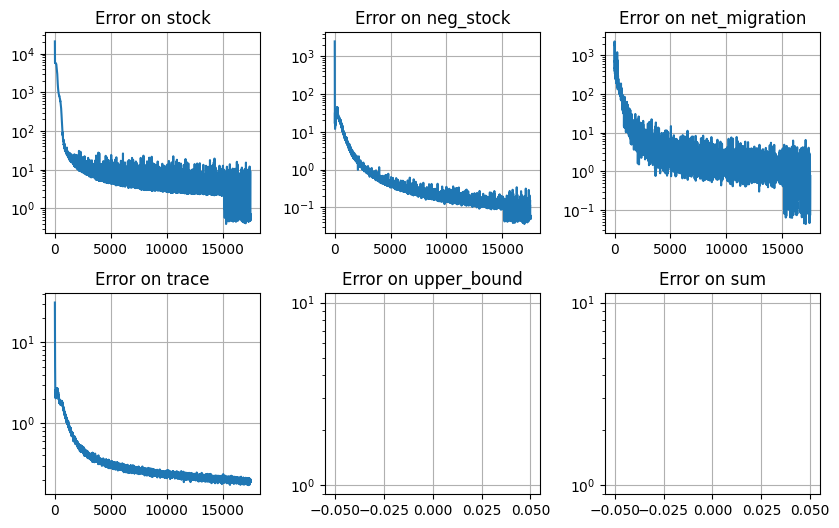

In [679]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(10, 6))
for idx, key in enumerate(loss_dict.keys()):
    ax = axs.flatten()[idx]
    ax.plot(np.arange(len(loss_dict[key])), loss_dict[key])
    ax.set_yscale('log')
    ax.set_title(f"Error on {key}")
    ax.grid()
fig.subplots_adjust(wspace=0.3, hspace=0.3)

Text(0.5, 1.0, 'Total loss')

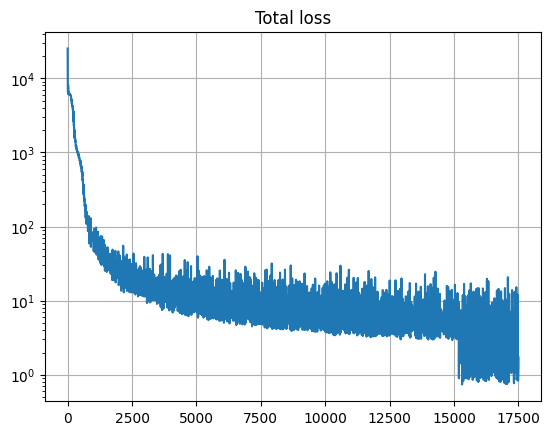

In [680]:
fig, ax = plt.subplots()
# ax.plot(np.convolve(loss_dict[key], np.ones(1000)/1000, mode='valid'))#
ax.plot(np.arange(len(loss_dict['stock'])), np.sum(np.stack([np.array(list(v)) for v in loss_dict.values() if list(v)]), axis=0))
ax.grid()
ax.set_yscale('log')
ax.set_title("Total loss")

In [693]:
predictions.to_netcdf("/Users/thomasgaskin/UN_migration_data/bilateral_flows.nc")

In [681]:
# Generate data arrays of predictions
predictions = NN(mu_rescaled).reshape(-1, 2, N, N).detach() * BM * alpha.reshape(Y, 1, 1, 1)
# predictions = torch.from_numpy(xr.load_dataarray("/Users/thomasgaskin/UN_migration_data/bilateral_flows.nc").data)
flows = predictions[:, 0, :] + predictions.transpose(-2, -1)[:, 1, :]
predictions = xr.DataArray(
    data=predictions,
    dims=["Year", "Direction", "Citizen ISO", "Partner ISO"],
    coords={"Year": net_migration.coords["Year"].data, "Direction": ["Out", "In"], "Citizen ISO": UN_data.coords["Country ISO"].data, 
            "Partner ISO": UN_data.coords["Country ISO"].data}
)
predicted_net_migration = xr.DataArray(
    data=flows.transpose(-2, -1).sum(dim=2) - flows.sum(dim=2),
    dims=["Year", "Country ISO"],
    coords={"Year": net_migration.coords["Year"].data, "Country ISO": UN_data.coords["Country ISO"].data}
)
flows = xr.DataArray(
    data=flows, 
    dims=["Year", "Origin ISO", "Destination ISO"], 
    coords={"Year": net_migration.coords["Year"].data, "Origin ISO": UN_data.coords["Country ISO"].data, "Destination ISO": UN_data.coords["Country ISO"].data}
)

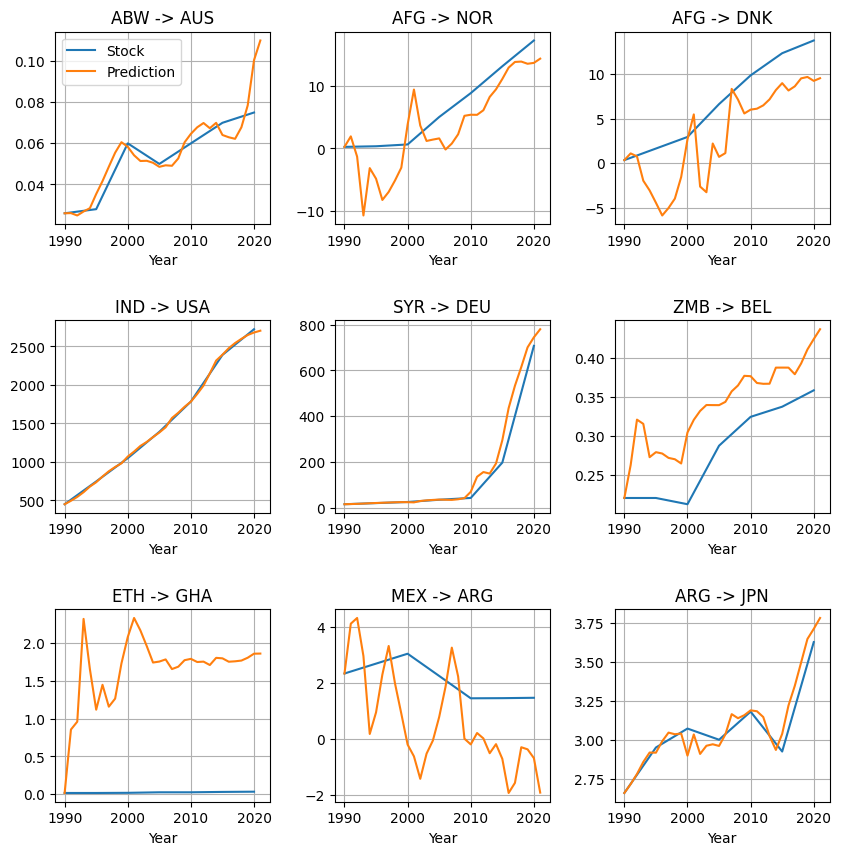

In [682]:
# Plot some examples
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10), gridspec_kw=dict(hspace=0.5, wspace=0.3))
for idx, (org, dest) in enumerate([("ABW", "AUS"), ("AFG", "NOR"), ("AFG", "DNK"), ("IND", "USA"), ("SYR", "DEU"), ("ZMB", "BEL"), ("ETH", "GHA"), ("MEX", "ARG"), ("ARG", "JPN")]):
    ax = axs.flatten()[idx]
    stock_data.sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label="Stock") 
    
    stock = [stock_data.sel({"Year": start, "Origin ISO": org, "Destination ISO": dest}).data]
    for y in predictions.coords["Year"].data[1:]: 
        stock.append(
            stock[-1] + predictions.sel({"Citizen ISO": org, "Partner ISO": dest, "Direction": "Out", "Year": y}, drop=True) - predictions.sel({"Citizen ISO": org, "Partner ISO": dest, "Direction": "In", "Year": y}, drop=True)
        )
    ax.plot(predictions.coords["Year"].data, np.array(stock), label="Prediction")
    ax.grid()
    ax.set_title(f"{org} -> {dest}")
axs[0, 0].legend()

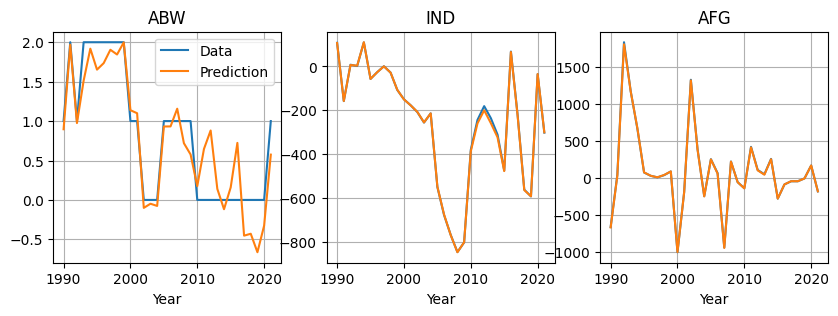

In [683]:
fig, axs = plt.subplots(ncols=3, figsize=(10, 3))
for idx, c in enumerate(["ABW", "IND", "AFG"]):
    ax =axs[idx]
    net_migration.sel({"Country ISO": c}).plot(ax=ax, label="Data")
    (predicted_net_migration.sel({"Country ISO": c})).plot(ax=ax, label="Prediction")
    ax.grid()
    ax.set_title(f"{c}")
axs[0].legend()

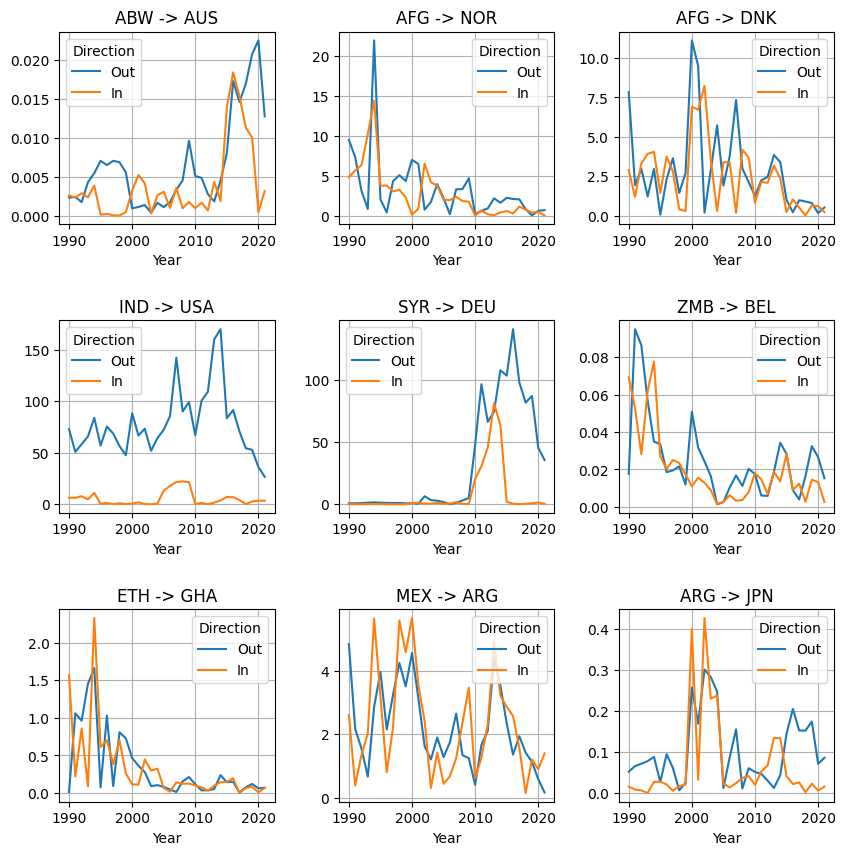

In [684]:
# Plot some examples
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10), gridspec_kw=dict(hspace=0.5, wspace=0.3))
for idx, (org, dest) in enumerate([("ABW", "AUS"), ("AFG", "NOR"), ("AFG", "DNK"), ("IND", "USA"), ("SYR", "DEU"), ("ZMB", "BEL"), ("ETH", "GHA"), ("MEX", "ARG"), ("ARG", "JPN")]):
    ax = axs.flatten()[idx]
    
    predictions.sel({"Citizen ISO": org, "Partner ISO": dest}).plot(ax=ax, hue="Direction")
    ax.grid()
    ax.set_title(f"{org} -> {dest}")

In [685]:
pred_five_year_estimates = []
for y in [1990, 1995, 2000, 2005, 2010, 2015]:
    pred_five_year_estimates.append(
        predictions.sel({"Direction": "Out", "Year": range(y, y+5)}).sum("Year")
    )
pred_five_year_estimates = xr.concat(pred_five_year_estimates, dim=pd.Index([1990, 1995, 2000, 2005, 2010, 2015], name="Year0"))

In [686]:
pred_five_year_estimates = pred_five_year_estimates.rename({"Citizen ISO": "Origin ISO", "Partner ISO": "Destination ISO"}) * 1000

---
# Add to Correlation csv
---

In [687]:
bilat = pd.read_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/bilat.csv")
bilat['edge'] = list(zip(bilat['orig'], bilat['dest']))
bilat.drop(["orig", "dest"], inplace=True, axis=1)
cols = list(bilat)
cols.insert(0, cols.pop(cols.index('edge')))
bilat = bilat.loc[:, cols]
bilat = bilat.set_index(["collection", "method"])
for collection in ['un_desa_imfsc', 'demig_c2c', 'eurostat', 'ilo_asean']:

    test = bilat[(bilat.index.get_level_values('collection') == collection) & (bilat.index.get_level_values('method') == 'da_pb_closed') & (bilat.definition == "residence")].drop_duplicates()

    new_method = []

    for idx, row in test.iterrows():
        if row['edge'][0] not in pred_five_year_estimates.coords["Origin ISO"].data or row['edge'][1] not in pred_five_year_estimates.coords["Destination ISO"].data:
            continue
        row['est_flow'] = pred_five_year_estimates.sel({"Year0": row['year0'], "Origin ISO": row['edge'][0], "Destination ISO": row['edge'][1]}).data
        row['est_tot'] = pred_five_year_estimates.sel({"Year0": row['year0'], "Destination ISO": row['edge'][1]}).sum("Origin ISO").data
        row.name = (row.name[0], 'NN')
        new_method.append(row)

    NN_ests = pd.concat(new_method, axis=1).T
    NN_ests.index = NN_ests.index.set_names(['collection', 'method'])

    bilat = pd.concat([bilat, NN_ests], axis=0)
bilat = bilat.reset_index()
bilat['orig'] = [x[0] for x in bilat['edge']]
bilat['dest'] = [x[1] for x in bilat['edge']]
bilat.drop('edge', axis=1, inplace=True)

In [691]:
bilat.to_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/bilat_new_2.csv", index=False)

In [688]:
totals = pd.read_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/totals.csv")
totals = totals.set_index(['collection', 'method']).drop_duplicates()
for collection in ['un_desa_imfsc', 'demig_tot', 'eurostat', 'ilo_asean', 'un_desa_wpp', 'ipums']:
    
    test = totals[(totals.index.get_level_values('collection') == collection) & (totals.index.get_level_values('method') == 'da_pb_closed') & (totals.definition == "residence")].drop_duplicates()
    
    new_method = []
    
    for idx, row in test.iterrows():
        if row['iso3c'] not in predicted_net_migration.coords["Country ISO"].data:
            continue
        row['emi'] = (predictions.sel({"Citizen ISO": row["iso3c"], "Direction": "Out", "Year": range(row['year0'], row['year0']+5)}).sum(["Partner ISO", "Year"])).data.item()
        row['imm'] = (predictions.sel({"Partner ISO": row["iso3c"], "Direction": "Out", "Year": range(row['year0'], row['year0']+5)}).sum(["Citizen ISO", "Year"])).data.item()
        row['net'] = row['imm'] - row['emi']
        row.name = (row.name[0], 'NN')
        new_method.append(row)

    NN_ests = pd.concat(new_method, axis=1).T
    NN_ests.index = NN_ests.index.set_names(['collection', 'method'])
    
    totals = pd.concat([totals, NN_ests], axis=0)
totals = totals.reset_index()

In [692]:
totals.to_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/totals_new_2.csv", index=False)

In [689]:
undesa = bilat[bilat.collection == 'un_desa_imfsc'][['est_flow', 'rep_flow', 'est_tot', 'rep_tot', 'orig', 'dest', 'year0', 'method']]
undesa = undesa.set_index(['year0', 'orig', 'dest', 'method'])
undesa = undesa[~undesa.index.duplicated()].to_xarray().astype(float)

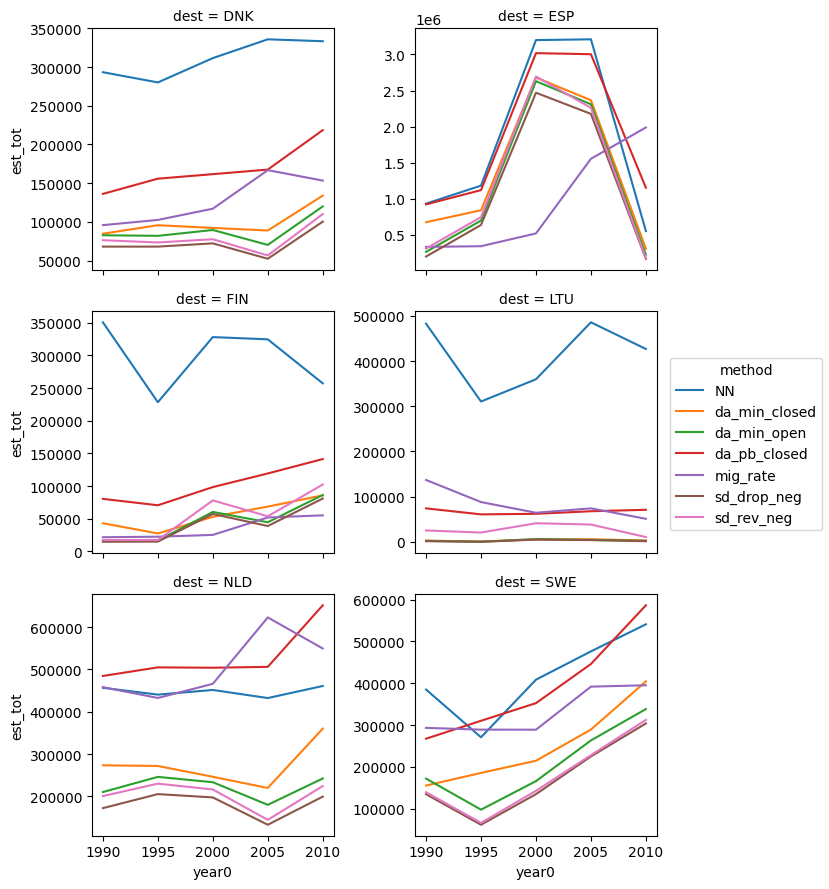

In [690]:
undesa.sel({"orig": "AFG"}).dropna("dest")["est_tot"].plot(col="dest", hue="method", col_wrap=2, sharey=False)